# Bengio et al. (2003): A Neural Probabilistic Language Model, from scratch

This notebook rebuilds the core idea of **Bengio, Ducharme, Vincent & Jauvin (2003), *A Neural Probabilistic Language Model***
on a tiny 12-word corpus, then looks closely at what the model did and did not learn.

**The one-sentence idea of the paper:** give every word a small learned vector (an *embedding*), feed the vectors of the
previous few words into a neural network, and train it to predict the next word. Because similar words end up with
similar vectors, what the model learns about one word carries over to the others. That is how the paper beats counting-based n-gram models.

**What we will find on our toy corpus:**
1. The loss stops at about **0.139** and can never reach 0, and we can work that number out by hand.
2. `cat` does **not** end up close to `dog`, but `mat` ends up close to `the`, which is not what we wanted.
3. The **loss curve** explains why: once the loss flattens, the embeddings almost stop moving.
4. The relationships we hoped for (`cat`≈`dog`, `mat`≈`rug`) never form, and we can find the exact causes and fix them.

A glossary of every term is at the bottom. Terms appear in **bold** where they are first explained.

## 0. Setup

In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

torch.set_printoptions(precision=3, sci_mode=False)

## 1. Corpus and vocabulary

- **Corpus**: the body of text we train on. Ours is a single string of 12 words.
- **Token**: one unit of text, here one word. `.split()` breaks the string on spaces into a list of tokens.
- **Vocabulary**: the set of *distinct* tokens. We sort it so the order (and therefore every index below) is always the same.
- **Index mapping**: neural networks work with numbers, not strings, so every word gets an integer ID.
  `word_to_idx` goes word → number and `idx_to_word` goes number → word, which we need to read the model's answers.

In [2]:
text = "the cat sat on the mat the dog sat on the rug".split()
vocab = sorted(set(text))                       # unique words, in a fixed order
word_to_idx = {w: i for i, w in enumerate(vocab)}
idx_to_word = {i: w for w, i in word_to_idx.items()}
V = len(vocab)                                  # vocabulary size

print("tokens:", text, f"({len(text)} tokens)")
print("vocab :", word_to_idx, f"(V = {V})")

tokens: ['the', 'cat', 'sat', 'on', 'the', 'mat', 'the', 'dog', 'sat', 'on', 'the', 'rug'] (12 tokens)
vocab : {'cat': 0, 'dog': 1, 'mat': 2, 'on': 3, 'rug': 4, 'sat': 5, 'the': 6} (V = 7)


## 2. Training examples: context → target

A language model predicts the next word from the words before it.

- **Context window (`n`)**: we look at an **n-gram**, a run of `n` consecutive words. The first `n-1` words are the **context**
  (what the model is allowed to see), and the last word is the **target** (what it must guess). With `n = 3`, each prediction uses the 2 previous words.
- Sliding this window across 12 tokens gives `12 - (n-1) = 10` training examples.
- `X` holds the contexts (shape `[10, 2]`) and `Y` holds the targets (shape `[10]`), as integer **tensors**.
  (A tensor is PyTorch's multi-dimensional array.)

Look carefully at the table. Two details here drive everything later on.

In [3]:
n = 3
contexts, targets = [], []
for i in range(n - 1, len(text)):
    ctx = text[i - (n - 1) : i]
    tgt = text[i]
    contexts.append([word_to_idx[w] for w in ctx])
    targets.append(word_to_idx[tgt])

X = torch.tensor(contexts)
Y = torch.tensor(targets)

for c, t in zip(contexts, targets):
    print(f"({idx_to_word[c[0]]:>3}, {idx_to_word[c[1]]:>3})  ->  {idx_to_word[t]}")

(the, cat)  ->  sat
(cat, sat)  ->  on
(sat,  on)  ->  the
( on, the)  ->  mat
(the, mat)  ->  the
(mat, the)  ->  dog
(the, dog)  ->  sat
(dog, sat)  ->  on
(sat,  on)  ->  the
( on, the)  ->  rug


Notice:
- **`(on, the)` appears twice with two different answers**: once `mat`, once `rug`. (Section 7 depends on this.)
- **`rug` never appears in a context.** It is the last word of the corpus, so it is only ever a target. (Section 10 depends on this.)
- `(the, cat) → sat` and `(the, dog) → sat`: `cat` and `dog` play *exactly* the same role. This is the relationship we hope the model will find.

## 3. The embedding matrix `C`

- **Embedding**: a dense vector of real numbers that represents a word. Bengio calls it a *distributed feature vector*:
  the meaning is spread across all dimensions instead of stored in a single slot.
- **Embedding matrix `C`**: shape `[V, m]`, one row per word. Row `i` is the embedding of word `i`.
  `m = 5` is the embedding dimension (how many numbers describe each word).
- It starts **random**. Training is what should turn it into something meaningful.
- `requires_grad=True` tells PyTorch to track operations on this tensor so it can compute **gradients** for it later (see Section 6).
- **Random seed**: `torch.Generator().manual_seed(42)` makes the "random" numbers the same every run, so results are **reproducible**.
- **Embedding lookup**: `C[X]` picks a row of `C` for every index in `X`. Shape `[10, 2]` → `[10, 2, 5]`.
- **Concatenation**: `.view(10, -1)` places the 2 context vectors side by side into one vector of length `2 × 5 = 10`.
  Word order is kept: the first 5 numbers are always the first context word.

In [4]:
m = 5
g = torch.Generator().manual_seed(42)
C = torch.randn(V, m, generator=g, requires_grad=True)

emb = C[X]                        # [10, 2, 5]  one vector per context word
x = emb.view(X.shape[0], -1)      # [10, 10]    the two vectors concatenated
print("C  :", tuple(C.shape))
print("emb:", tuple(emb.shape))
print("x  :", tuple(x.shape))

C  : (7, 5)
emb: (10, 2, 5)
x  : (10, 10)


## 4. The network

Bengio's model computes a score for every word in the vocabulary:

$$ y = b + xW + \tanh(xH + d)\,U $$

| piece | shape | what it is |
|---|---|---|
| `H`, `d` | `[10, 8]`, `[8]` | **hidden layer** weights and **bias**. With `h = 8` hidden units, this is a middle layer where the network can combine features. |
| `tanh` | | **activation function**, which squashes values into (-1, 1). Without a non-linearity, stacked layers would collapse into one linear map. |
| `U` | `[8, V]` | hidden layer → one score per vocabulary word |
| `W` | `[10, V]` | **direct connection** from the input straight to the output, skipping the hidden layer (optional in the paper). |
| `b` | `[V]` | output bias, a baseline score per word (roughly "how common is this word overall") |

- **Logits** (`y`): the raw, unnormalised scores, one per word. They can be any real number.
- **Softmax** turns logits into a **probability distribution**: `exp(y_i) / Σ exp(y_j)`. Every value is positive and they sum to 1.
- **Parameters**: all the numbers the model is allowed to change during training: `C, H, d, U, W, b`.

Below we create them from the *same* generator `g`, in the same order as before, so the random start is reproducible.

In [5]:
h = 8
H = torch.randn((n - 1) * m, h, generator=g, requires_grad=True)
d = torch.randn(h, generator=g, requires_grad=True)
U = torch.randn(h, V, generator=g, requires_grad=True)
W = torch.randn((n - 1) * m, V, generator=g, requires_grad=True)
b = torch.randn(V, generator=g, requires_grad=True)
params = [C, H, d, U, W, b]

n_params = sum(p.numel() for p in params)
print(f"parameters: {n_params}   training examples: {len(Y)}")

parameters: 256   training examples: 10


**Keep this ratio in mind: 256 parameters for 10 examples.** A model with far more free numbers than data points can
**memorise** each example individually instead of learning a general rule. This is **overfitting** / **overparameterisation**.
The direct connection `W` makes memorising especially easy: a linear map from the 10-number input straight to the answer is enough to fit each example.

## 5. The loss: cross-entropy

**Loss**: one number that measures how wrong the model is. Training tries to make it small.

For each example we look at the probability the model gave to the **correct** target, `p_true`, and take `-log(p_true)`:
- `p_true = 1` gives loss 0 (perfect)
- `p_true = 0.5` gives loss 0.693
- `p_true → 0` gives a loss that goes to infinity

Averaged over examples, this is the **cross-entropy loss** (also called **negative log-likelihood**).
`F.cross_entropy(y, Y)` does softmax + pick `p_true` + `-log` + mean in one numerically stable step. The manual version and the built-in agree:

In [6]:
y = b + x @ W + torch.tanh(x @ H + d) @ U       # logits, [10, V]
probs = F.softmax(y, dim=1)                     # each row sums to 1
p_true = probs[torch.arange(len(Y)), Y]         # prob. of the correct word per example
manual = -torch.log(p_true).mean()
print(f"manual: {manual.item():.4f}   F.cross_entropy: {F.cross_entropy(y, Y).item():.4f}")
print(f"a uniform guess would give ln(V) = {torch.log(torch.tensor(float(V))).item():.4f}")

manual: 6.4091   F.cross_entropy: 6.4091
a uniform guess would give ln(V) = 1.9459


The untrained model scores *worse* than guessing uniformly: random weights give it confident, wrong opinions.

## 6. Training

One **training step**:
1. **Forward pass**: compute the logits and the loss from the current parameters.
2. **Zero the gradients** (`p.grad = None`): PyTorch *adds* new gradients to old ones, so we clear them first.
3. **Backward pass** (`loss.backward()`): **backpropagation** computes each parameter's **gradient**, which says
   in which direction and how strongly to change that number to *increase* the loss.
4. **Update**: move every parameter a small step the *other* way: `p -= lr * p.grad`. This is **gradient descent**.
   `lr` (the **learning rate**) is the step size.
   The update is inside `torch.no_grad()` because the update itself should not be recorded as part of the computation graph.

An **important consequence** for embeddings: `C[X]` only touches the rows of `C` for words that appear in a context.
**A word's embedding only gets a gradient when that word is in a context.** A word that is only ever a target never has its embedding updated.

We also keep a copy of `C` at every step so we can watch the embeddings move.

In [7]:
C_before = C.detach().clone()      # snapshot of the random starting embeddings
lr = 0.1
steps = 1000
losses, C_history = [], [C_before]

for step in range(steps):
    emb = C[X]
    x = emb.view(X.shape[0], -1)
    hidden = torch.tanh(x @ H + d)
    y = b + x @ W + hidden @ U
    loss = F.cross_entropy(y, Y)

    for p in params:
        p.grad = None
    loss.backward()

    with torch.no_grad():
        for p in params:
            p -= lr * p.grad

    losses.append(loss.item())
    C_history.append(C.detach().clone())
    if step % 100 == 0 or step == steps - 1:
        print(f"step {step:4d}  loss {loss.item():.4f}")

step    0  loss 6.4091
step  100  loss 0.1761
step  200  loss 0.1553
step  300  loss 0.1493
step  400  loss 0.1465
step  500  loss 0.1448


step  600  loss 0.1436


step  700  loss 0.1429
step  800  loss 0.1423
step  900  loss 0.1418
step  999  loss 0.1415


## 7. Why the loss never reaches 0

The loss falls quickly from 6.4, then slows to a crawl around **0.14**. The reason is in the corpus, not the model.

Recall from Section 2: the context `(on, the)` appears **twice**, once followed by `mat` and once by `rug`.
The model sees identical inputs, so it *must* produce identical probabilities for both. Whatever it assigns, call it
`p` for `mat` and `1-p` for `rug`, the two examples together cost `-log(p) - log(1-p)`, which is smallest at `p = 0.5`.
The best achievable cost is then `2 × ln 2`.

Every other context has a single, certain answer, so the model can drive those to (almost) 0 loss. Averaged over 10 examples:

$$\text{loss floor} = \frac{2\ln 2}{10} \approx 0.1386$$

This is the **irreducible loss**, also called the *Bayes error* or the **entropy** of the data. It is the uncertainty that is really in the text:
no model, however large, can know whether "on the" is followed by "mat" or "rug", because in this corpus it is both, equally often.
Real language is full of this. That is why real language models never reach 0 loss either.

In [8]:
import math
floor = 2 * math.log(2) / len(Y)
print(f"theoretical floor: {floor:.4f}")
print(f"final loss       : {losses[-1]:.4f}   (gap {losses[-1] - floor:.4f}, still shrinking slowly)")

with torch.no_grad():
    ctx = torch.tensor([[word_to_idx["on"], word_to_idx["the"]]])
    p = F.softmax(b + C[ctx].view(1, -1) @ W + torch.tanh(C[ctx].view(1, -1) @ H + d) @ U, dim=1)[0]
print("\nP(next word | 'on the'):")
for i in p.argsort(descending=True)[:3]:
    print(f"  {idx_to_word[i.item()]:>4}: {p[i].item():.3f}")

theoretical floor: 0.1386
final loss       : 0.1415   (gap 0.0029, still shrinking slowly)

P(next word | 'on the'):
   mat: 0.499
   rug: 0.499
   the: 0.001


The model has learned what the data actually says: after "on the", it's a coin flip between `mat` and `rug`.

## 8. Did the embeddings learn meaning? Nearest neighbours

**Cosine similarity** measures how closely two vectors point in the same direction, ignoring their length:

$$\cos(a, b) = \frac{a \cdot b}{\lVert a\rVert\,\lVert b\rVert} \in [-1, 1]$$

`1` means the same direction, `0` means unrelated (orthogonal), and `-1` means opposite. If embeddings capture meaning,
words used the same way should have cosine similarity close to 1. The function below ranks every word by its similarity to a query word.

In [9]:
def neighbours(E, word):
    v = E[word_to_idx[word]]
    sims = (E @ v) / (E.norm(dim=1) * v.norm())
    order = sims.argsort(descending=True)
    return [(idx_to_word[i.item()], round(sims[i].item(), 3)) for i in order]

C_after = C.detach()
for w in ["cat", "mat"]:
    print(f"{w} before: {neighbours(C_before, w)}")
    print(f"{w} after : {neighbours(C_after, w)}\n")

cat before: [('cat', 1.0), ('on', 0.688), ('sat', 0.637), ('rug', 0.568), ('dog', -0.128), ('mat', -0.442), ('the', -0.854)]
cat after : [('cat', 1.0), ('sat', 0.806), ('on', 0.744), ('rug', 0.363), ('dog', 0.128), ('mat', -0.624), ('the', -0.92)]

mat before: [('mat', 1.0), ('the', 0.412), ('rug', 0.351), ('dog', 0.169), ('cat', -0.442), ('sat', -0.496), ('on', -0.734)]
mat after : [('mat', 1.0), ('the', 0.505), ('rug', 0.226), ('dog', -0.189), ('on', -0.448), ('sat', -0.521), ('cat', -0.624)]



### What we see

- **`cat` is not similar to `dog`.** They are fifth in `cat`'s ranking, at about 0.13. The closest words are `sat` and `on`.
- **`mat` is most similar to `the`**, not to `rug`, even though `mat` and `rug` are the two words that can follow "on the".

### Why, in short

**Compare the "before" and "after" lists: the ranking barely changed.** `cat`'s top neighbours were `on` and `sat`
*before any training*, and `mat`–`the` was already the closest pair (0.41) at random initialisation.
Training did move the numbers (e.g. `cat`–`sat` 0.64 → 0.81), but mostly *reinforced* the existing order. **Most of the neighbour ranking comes from the random starting point, not from learning.**

- `mat ≈ the` is **left over from the random start**. Nothing in the data says they are alike. They were close by chance and training did not pull them apart.
- `cat` vs `dog` *did* move toward each other (from -0.13 to +0.13), but not very far. Section 9 shows why it stopped.

## 9. How the loss curve controls the embeddings

The update rule is `p -= lr * p.grad`. **When the gradients are ~0, the parameters barely change.** Gradients shrink as the loss
approaches its floor, so once the loss flattens, the embeddings are almost frozen where they are.

The three panels share the same x-axis (training step):
1. **Loss** on a **log scale** (otherwise the flat part after step ~50 looks like a straight line at 0), with the 0.1386 floor.
2. **How far each word's embedding has moved** from its random start: `‖C_t[w] − C_0[w]‖`.
3. **Cosine similarity of the pairs we care about**, tracked over training.

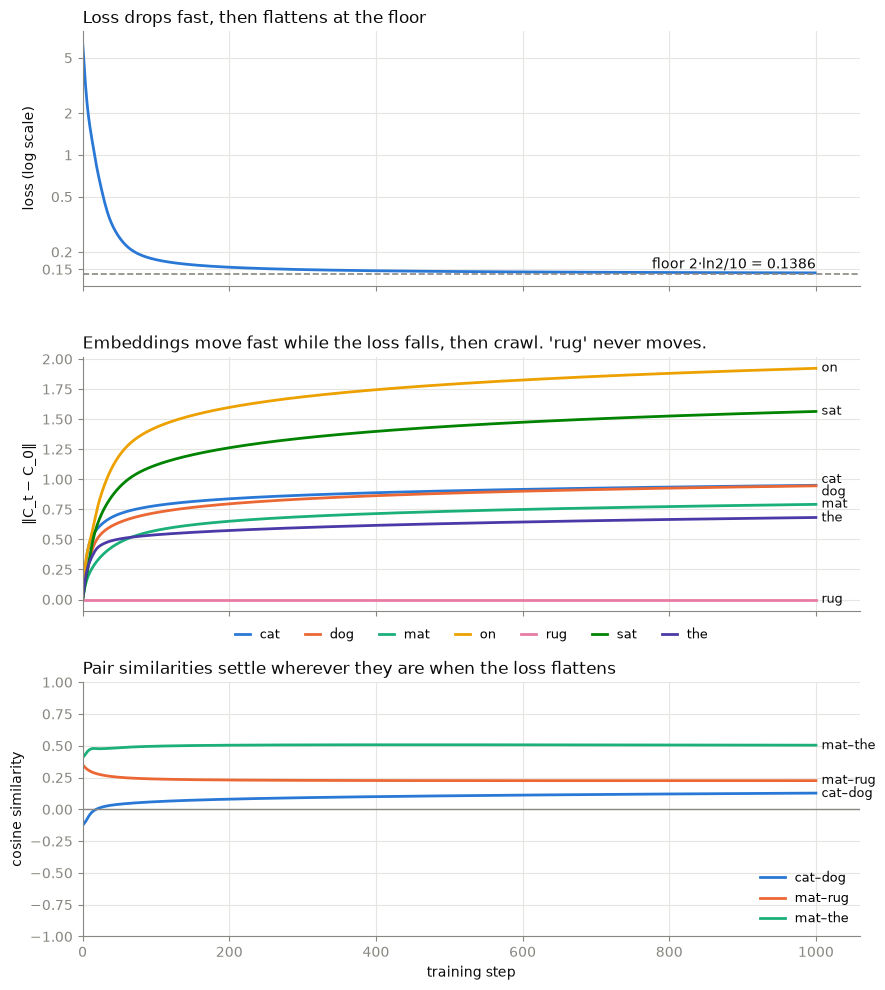

In [10]:
Ch = torch.stack(C_history)                      # [steps+1, V, m]
drift = (Ch - Ch[0]).norm(dim=2)                 # distance moved, per step per word
cos = lambda a, c: F.cosine_similarity(Ch[:, word_to_idx[a]], Ch[:, word_to_idx[c]], dim=1)

SERIES = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7"]
INK, MUTED, GRID = "#0b0b0b", "#898781", "#e6e5e1"
plt.rcParams.update({"axes.edgecolor": MUTED, "axes.labelcolor": INK, "xtick.color": MUTED,
                     "ytick.color": MUTED, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8, "font.size": 10})

fig, axes = plt.subplots(3, 1, figsize=(9, 10), sharex=True)
t = range(len(losses))

ax = axes[0]
ax.plot(t, losses, color=SERIES[0], lw=2)
ax.axhline(floor, color=MUTED, ls="--", lw=1.2)
ax.text(steps, floor * 1.04, f"floor 2·ln2/10 = {floor:.4f}", ha="right", va="bottom", color=INK)
ax.set_yscale("log"); ax.set_ylabel("loss (log scale)")
ax.set_yticks([0.15, 0.2, 0.5, 1, 2, 5]); ax.set_yticklabels(["0.15", "0.2", "0.5", "1", "2", "5"])
ax.minorticks_off()
ax.set_title("Loss drops fast, then flattens at the floor", loc="left", color=INK)

ax = axes[1]
for i, w in enumerate(vocab):
    ax.plot(range(len(Ch)), drift[:, i], color=SERIES[i], lw=2, label=w)
    dy = {"cat": 4, "dog": -4}.get(w, 0)   # nudge the two overlapping end labels apart
    ax.annotate(w, (len(Ch) - 1, drift[-1, i].item()), xytext=(4, dy), textcoords="offset points",
                va="center", color=INK, fontsize=9)
ax.set_ylabel("‖C_t − C_0‖")
ax.set_title("Embeddings move fast while the loss falls, then crawl. 'rug' never moves.", loc="left", color=INK)
ax.legend(ncol=7, frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.02), fontsize=9, handlelength=1.2)

ax = axes[2]
for j, (a, c) in enumerate([("cat", "dog"), ("mat", "rug"), ("mat", "the")]):
    s = cos(a, c)
    ax.plot(range(len(Ch)), s, color=SERIES[j], lw=2, label=f"{a}–{c}")
    ax.annotate(f"{a}–{c}", (len(Ch) - 1, s[-1].item()), xytext=(4, 0), textcoords="offset points",
                va="center", color=INK, fontsize=9)
ax.axhline(0, color=MUTED, lw=1)
ax.set_ylim(-1, 1); ax.set_ylabel("cosine similarity"); ax.set_xlabel("training step")
ax.set_title("Pair similarities settle wherever they are when the loss flattens", loc="left", color=INK)
ax.legend(frameon=False, loc="lower right", fontsize=9)

for ax in axes:
    ax.set_xlim(0, steps + 60)
fig.tight_layout()
plt.show()

In [11]:
print("distance each embedding moved from its random start (compare to its starting length):")
for i, w in enumerate(vocab):
    print(f"  {w:>4}: moved {drift[-1, i].item():.3f}   starting length {C_before[i].norm().item():.3f}")

distance each embedding moved from its random start (compare to its starting length):
   cat: moved 0.949   starting length 3.410
   dog: moved 0.945   starting length 2.718
   mat: moved 0.791   starting length 1.886
    on: moved 1.922   starting length 2.550
   rug: moved 0.000   starting length 0.988
   sat: moved 1.564   starting length 3.012
   the: moved 0.682   starting length 2.140


### Reading the curves

- Most of the movement happens in the **first ~100 steps**, while the loss drops from 6.4 to ~0.18. After that the loss is
  close to the floor and the gradients are small. The embeddings keep creeping (mostly growing longer), but the **directions**
  barely change, and cosine similarity only measures direction. Panel 3 shows it clearly: the pair similarities are flat after the first few dozen steps.
- Every embedding moved *less than its own length*. The final vectors are still mostly the **random initial vectors** plus a small correction.
  That is why the "before" and "after" neighbour lists in Section 8 look so alike.
- **The loss curve and the embeddings are linked.** Embeddings only learn anything meaningful *while the loss is still falling*.
  The model reached the floor by memorising 10 examples, long before it had any reason to organise the embeddings.
  A low loss here tells you the training data is fitted. It does *not* tell you the embeddings mean anything.

## 10. Why `cat`≈`dog` and `mat`≈`rug` never formed

These two failures have **different causes**.

### `mat` / `rug`: `rug`'s embedding is never trained

From Section 6: a word's row in `C` only gets a gradient when that word appears in a **context**. `rug` is the last word of the corpus,
so it is only ever a *target*. Its embedding receives **exactly zero gradient** and stays at its random initial value forever.
(`mat` and `rug` *do* get similar treatment on the **output** side, in the columns of `U`, `W` and `b` that score them as predictions,
but those are not the vectors we measure similarity with.)

In [12]:
for w in ["cat", "dog", "mat", "rug"]:
    n_ctx = sum(word_to_idx[w] in c for c in contexts)
    unchanged = torch.equal(C_before[word_to_idx[w]], C_after[word_to_idx[w]])
    print(f"{w:>4}: appears in {n_ctx} context(s)   embedding unchanged after training: {unchanged}")

 cat: appears in 2 context(s)   embedding unchanged after training: False
 dog: appears in 2 context(s)   embedding unchanged after training: False
 mat: appears in 2 context(s)   embedding unchanged after training: False
 rug: appears in 0 context(s)   embedding unchanged after training: True


### `cat` / `dog`: the pull toward each other is real, but weak and short-lived

`cat` and `dog` have **identical** contexts: `(the, _) → sat` and `(_, sat) → on`. So there *is* a reason for them to become similar.
But:
1. **Only 2 examples each.** The signal pulling them together is tiny.
2. **Nothing requires them to be similar.** The network (especially the direct connection `W`) can map two *different* vectors to the same prediction.
   With 256 parameters for 10 examples, it has plenty of ways to fit both without merging them. Being similar would be one valid solution, but only one among many.
3. **Training stops early** (Section 9). Once the examples are fitted, the gradient vanishes and the small pull stops.

So the final `cat`–`dog` similarity is: *random start + a small nudge toward each other*. Seed 42 happened to start them at -0.13,
so the nudge only got them to +0.13. To check that this is not specific to seed 42, we re-run the same training from 20 random seeds:

In [13]:
def train(text, seed=42, steps=1000, lr=0.1, weight_decay=0.0, m=5, h=8, n=3):
    # Same model and training as above, wrapped in a function so we can re-run it.
    # weight_decay adds weight_decay * sum(p**2) to the loss (explained in Section 11).
    tokens = text.split()
    vocab = sorted(set(tokens))
    w2i = {w: i for i, w in enumerate(vocab)}
    V = len(vocab)
    X = torch.tensor([[w2i[w] for w in tokens[i - (n - 1) : i]] for i in range(n - 1, len(tokens))])
    Y = torch.tensor([w2i[w] for w in tokens[n - 1 :]])

    g = torch.Generator().manual_seed(seed)
    C = torch.randn(V, m, generator=g, requires_grad=True)
    H = torch.randn((n - 1) * m, h, generator=g, requires_grad=True)
    d = torch.randn(h, generator=g, requires_grad=True)
    U = torch.randn(h, V, generator=g, requires_grad=True)
    W = torch.randn((n - 1) * m, V, generator=g, requires_grad=True)
    b = torch.randn(V, generator=g, requires_grad=True)
    params = [C, H, d, U, W, b]
    C0 = C.detach().clone()

    for _ in range(steps):
        x = C[X].view(X.shape[0], -1)
        y = b + x @ W + torch.tanh(x @ H + d) @ U
        ce = F.cross_entropy(y, Y)                  # prediction loss only
        loss = ce + weight_decay * sum((p ** 2).sum() for p in params)
        for p in params:
            p.grad = None
        loss.backward()
        with torch.no_grad():
            for p in params:
                p -= lr * p.grad

    sim = lambda E, a, c: F.cosine_similarity(E[w2i[a]], E[w2i[c]], dim=0).item()
    pairs = [("cat", "dog"), ("mat", "rug"), ("mat", "the")]
    sims = {f"{a}–{c}": (sim(C0, a, c), sim(C.detach(), a, c)) for a, c in pairs}
    return sims, ce.item()

corpus = "the cat sat on the mat the dog sat on the rug"
runs = [train(corpus, seed=s)[0] for s in range(20)]

print(f"{'pair':>8} | {'mean before':>11} | {'mean after':>10} | runs where after > 0.9")
for k in runs[0]:
    before = sum(r[k][0] for r in runs) / len(runs)
    after = sum(r[k][1] for r in runs) / len(runs)
    close = sum(r[k][1] > 0.9 for r in runs)
    print(f"{k:>8} | {before:>11.2f} | {after:>10.2f} | {close}/20")

    pair | mean before | mean after | runs where after > 0.9
 cat–dog |       -0.02 |       0.29 | 1/20
 mat–rug |        0.08 |       0.03 | 0/20
 mat–the |       -0.24 |      -0.24 | 0/20


Across 20 random starts:
- **`cat`–`dog`** moves toward each other *on average*, but rarely becomes truly similar. The pull exists but is too weak to finish the job.
- **`mat`–`rug`** does not change on average, as expected, because `rug` is never trained.
- **`mat`–`the`** averages -0.24 both before and after training, so across seeds they are *not* similar. **The 0.5 we saw with seed 42 was luck from the random start**, not something the model learned.

## 11. Fixing it

If the diagnosis is right, two changes should fix it:

1. **More data, with `rug` in contexts** (e.g. put sentence breaks `.` between sentences, and use the words in more combinations). This gives `rug` gradients
   and gives every word more examples, so the pull toward similar words is stronger.
2. **Weight decay** (**L2 regularisation**): add `λ · Σ p²` to the loss, which penalises large parameters. Now "any solution that fits the data"
   is no longer enough; the model prefers the *smallest* one. If `cat` and `dog` behave identically, the cheapest solution is to give them the
   *same* vector, so the model gets **pressure to share** that it had no reason for before. This is the kind of pressure that, at scale,
   makes distributed representations generalise (the paper also trains with weight decay).

In [14]:
bigger = ("the cat sat on the mat . the dog sat on the rug . "
          "the dog sat on the mat . the cat sat on the rug . "
          "the cat lay on the mat . the dog lay on the rug .")

settings = [("original corpus", corpus, 0.0), ("original + weight decay", corpus, 0.01),
            ("bigger corpus", bigger, 0.0), ("bigger + weight decay", bigger, 0.01)]

print("mean over 10 seeds, 3000 steps. Pair columns = cosine similarity after training.")
print(f"{'setting':>24} | " + " | ".join(f"{k:>8}" for k in runs[0]) + " | CE loss")
for name, txt, wd in settings:
    out = [train(txt, seed=s, steps=3000, weight_decay=wd) for s in range(10)]
    rs, ces = [o[0] for o in out], [o[1] for o in out]
    row = [sum(r[k][1] for r in rs) / len(rs) for k in rs[0]]
    print(f"{name:>24} | " + " | ".join(f"{v:>8.2f}" for v in row) + f" | {sum(ces) / len(ces):.3f}")

mean over 10 seeds, 3000 steps. Pair columns = cosine similarity after training.
                 setting |  cat–dog |  mat–rug |  mat–the | CE loss


         original corpus |     0.37 |    -0.10 |    -0.23 | 0.140


 original + weight decay |     1.00 |    -0.14 |    -0.25 | 0.206


           bigger corpus |     0.51 |     0.62 |    -0.10 | 0.285


   bigger + weight decay |     1.00 |     1.00 |    -0.22 | 0.376


- **Weight decay alone** makes `cat`–`dog` nearly identical (≈1.0), because their roles were already identical and the model finally has a reason to share.
  It cannot fix `mat`–`rug` on the original corpus: `rug` still gets no gradient.
- **The bigger corpus** puts `rug` in contexts, so `mat`–`rug` starts to rise too.
- **Both together** give what we wanted from the start: `cat ≈ dog`, `mat ≈ rug`, and `mat` is *not* like `the`.
- The "original corpus" row shows `cat`–`dog` at 0.37 rather than the 0.29 in Section 10 because it trains for 3000 steps instead of 1000 (and over 10 seeds instead of 20). The weak pull keeps creeping.
- **Weight decay has a cost.** The CE (cross-entropy) loss rises above the floor (original floor 0.139, bigger corpus floor ≈ 0.284).
  The model gives up a little accuracy on the *training* data in exchange for simpler, shared structure. This is the classic
  **bias–variance trade-off**: a slightly worse fit to the examples you have, in return for representations that generalise to examples you haven't seen.

**Takeaway:** embeddings become meaningful only when (a) every word's vector gets trained, which means it must appear in contexts,
(b) there is enough shared context to push words together, and (c) something (limited capacity, regularisation, lots of data)
stops the model from just memorising. Our original setup had none of the three.

## Glossary

| term | meaning |
|---|---|
| **activation function** | a non-linear function applied inside a network (here `tanh`), so it can model more than straight lines |
| **backpropagation / `backward()`** | the algorithm that computes every parameter's gradient by applying the chain rule backward from the loss |
| **Bayes error / irreducible loss** | the lowest loss any model can reach, set by real ambiguity in the data |
| **bias–variance trade-off** | fitting training data less tightly (more bias) in exchange for more stable, better-generalising models (less variance) |
| **bias** | a learned constant added to a layer's output (`d`, `b`) |
| **concatenation** | joining vectors end to end (`.view(N, -1)` on the looked-up embeddings) |
| **context / target** | the words the model sees / the word it must predict |
| **context window (`n`)** | size of the n-gram; the model sees `n-1` previous words |
| **corpus** | the training text |
| **cosine similarity** | how closely two vectors point in the same direction, from -1 to 1, ignoring length |
| **cross-entropy / negative log-likelihood** | average of `-log(p_true)`; the standard loss for classification and language modelling |
| **direct connection (`W`)** | Bengio's optional shortcut from input embeddings straight to the output scores |
| **distributed representation** | meaning spread across many dimensions of a vector instead of one slot per word |
| **embedding / embedding matrix `C`** | a learned vector per word / the table holding all of them, one row per word |
| **embedding lookup** | `C[X]`: select rows of `C` by word index |
| **entropy** | the average uncertainty in a distribution; for a fair coin flip it is `ln 2` |
| **gradient** | for each parameter, the direction and rate at which the loss grows; we step the opposite way |
| **gradient descent** | repeatedly doing `p -= lr * grad` to lower the loss |
| **hidden layer** | an intermediate layer (`tanh(xH + d)`) between input and output |
| **learning rate (`lr`)** | the step size of each gradient-descent update |
| **logits** | raw, unnormalised output scores, before softmax |
| **loss** | a single number measuring how wrong the model is |
| **n-gram** | a run of `n` consecutive tokens |
| **overfitting / memorisation** | fitting the training examples individually instead of learning a general pattern; likely when parameters ≫ examples |
| **parameters** | the trainable numbers of the model (`C, H, d, U, W, b`) |
| **random seed** | fixes the random number generator so results are reproducible |
| **`requires_grad`** | tells PyTorch to track a tensor so gradients can be computed for it |
| **softmax** | turns logits into probabilities: `exp(y_i) / Σ exp(y_j)` |
| **tensor** | PyTorch's multi-dimensional array |
| **token** | one unit of text (here a word) |
| **`torch.no_grad()`** | a block where PyTorch does not record operations, used for parameter updates and evaluation |
| **vocabulary (`V`)** | the set of distinct tokens / its size |
| **weight decay / L2 regularisation** | adding `λ Σ p²` to the loss, which favours small parameters and pushes words with the same role to share a vector |
| **zeroing gradients** | clearing `.grad` before each backward pass, because PyTorch adds new gradients to old ones |